# Data & AI Challenge  
## Insurance Claims Fraud Detection

Trabajás con datos reales de siniestros de una aseguradora. El objetivo es mostrar tu capacidad de limpieza de datos, análisis de negocio y uso práctico de IA.

---

### Dataset
**Insurance Claims Fraud Data**

- 3 tablas:
  - `insurance_data` (10k filas)
  - `employee_data`
  - `vendor_data`

---

### Entrega

- **Límite:** Domingo 26/04 a las 18:00 hs  
- **Email:** rrhh@teknedatalabs.com  
- **Asunto:** *Challenge Data & AI - [Tu nombre]*

## Funciones

In [48]:
def analizar_nulos(df, nombre_df="DataFrame"):
    """
    Calcula y muestra los nulos y su porcentaje para un DataFrame dado.
    """
    nulos = df.isnull().sum()
    total = len(df)
    porcentaje = round((nulos / total) * 100, 2)
    
    # Crear reporte en un DataFrame
    df_nulos = pd.DataFrame({
        'Columna': nulos.index,
        'Nulos': nulos.values,
        'Porcentaje (%)': porcentaje.values
    })
    
    # Filtrar solo columnas con nulos y ordenar
    reporte = df_nulos[df_nulos['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)
    
    print(f"--- Análisis de Nulos: {nombre_df} ---")
    if reporte.empty:
        print("¡Excelente! No hay valores nulos en este DataFrame.")
    else:
        display(reporte)
    print("-" * 35 + "\n")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def detectar_outliers_iqr(df, cols, plot=True):
    resultados = []

    for col in cols:
        # Evitar columnas no numéricas
        if not np.issubdtype(df[col].dtype, np.number):
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        resultados.append({
            "columna": col,
            "outliers": outliers.shape[0],
            "%_outliers": round(outliers.shape[0] / df.shape[0] * 100, 2),
            "min": df[col].min(),
            "max": df[col].max()
        })

        # Boxplot
        if plot:
            plt.figure(figsize=(6, 2))
            sns.boxplot(x=df[col])
            plt.title(f"Boxplot - {col}")
            plt.axvline(lower, color='red', linestyle='--', label='Lower bound')
            plt.axvline(upper, color='green', linestyle='--', label='Upper bound')
            plt.legend()
            plt.show()

    return pd.DataFrame(resultados)



## 1. Data Engineering & Quality (35%)

**Entregable**

- Notebook o script + breve explicación de cada decisión tomada

### 1.1 Integrá las 3 tablas y describí brevemente el modelo de datos 

  *(qué representa cada una y cómo se relacionan)*

  - Tablas:
  - `insurance_data`
  - `employee_data`
  - `vendor_data`

**Lectura de los datasets**

In [2]:
import pandas as pd
import os

data_path = "dataset"

dfs = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        
        df_name = file.replace(".csv", "")
        
        df = pd.read_csv(file_path)
        dfs[df_name] = df
        
        print(f"\nDataFrame: {df_name}")
        print(f"Cantidad de filas: {df.shape[0]}")
        print("Primeras 5 filas:")
        display(df.head())
        print("Columnas:")
        print(df.info())
        print("---------------------------------\n")

# Acceso directo a cada DataFrame
insurance_data = dfs['insurance_data']
employee_data = dfs['employee_data']
vendor_data = dfs['vendor_data']



DataFrame: employee_data
Cantidad de filas: 1200
Primeras 5 filas:


,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,NaN,Waterbury Center,VT,5677,34584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,NaN,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,81744097,YSCJ67489688482590
3,AGENT00004,Mary Smith,2004-09-23,235 Hugh Thomas Drive,NaN,Panama City,FL,32404,67563771,ZANG21285355574581
4,AGENT00005,Mildred Diaz,2011-06-21,3426 Broadview Street,NaN,Montgomery,AL,36110,114951317,DZFS82244494451134


Columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   AGENT_ID            1200 non-null   object
 1   AGENT_NAME          1200 non-null   object
 2   DATE_OF_JOINING     1200 non-null   object
 3   ADDRESS_LINE1       1200 non-null   object
 4   ADDRESS_LINE2       179 non-null    object
 5   CITY                1193 non-null   object
 6   STATE               1200 non-null   object
 7   POSTAL_CODE         1200 non-null   int64 
 8   EMP_ROUTING_NUMBER  1200 non-null   int64 
 9   EMP_ACCT_NUMBER     1200 non-null   object
dtypes: int64(2), object(8)
memory usage: 93.9+ KB
None
---------------------------------


DataFrame: insurance_data
Cantidad de filas: 10000
Primeras 5 filas:


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,A,Minor Loss,Ambulance,0,0,GA,Savannah,12,AGENT00278,VNDR00075
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,A,Major Loss,Police,0,1,TN,Nashville,18,AGENT00636,VNDR00472


Columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TXN_DATE_TIME             10000 non-null  object 
 1   TRANSACTION_ID            10000 non-null  object 
 2   CUSTOMER_ID               10000 non-null  object 
 3   POLICY_NUMBER             10000 non-null  object 
 4   POLICY_EFF_DT             10000 non-null  object 
 5   LOSS_DT                   10000 non-null  object 
 6   REPORT_DT                 10000 non-null  object 
 7   INSURANCE_TYPE            10000 non-null  object 
 8   PREMIUM_AMOUNT            10000 non-null  float64
 9   CLAIM_AMOUNT              10000 non-null  int64  
 10  CUSTOMER_NAME             10000 non-null  object 
 11  ADDRESS_LINE1             10000 non-null  object 
 12  ADDRESS_LINE2             1495 non-null   object 
 13  CITY                      9946 non-null   object 
 1

,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,NaN,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,NaN,Montgomery,AL,36109
3,VNDR00004,Mays-Benson,227 West Montgomery Cross Road,#736,Savannah,GA,31406
4,VNDR00005,Wilson PLC,23 North Hill Street,NaN,Nashville,TN,37210


Columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   VENDOR_ID      600 non-null    object
 1   VENDOR_NAME    600 non-null    object
 2   ADDRESS_LINE1  600 non-null    object
 3   ADDRESS_LINE2  97 non-null     object
 4   CITY           594 non-null    object
 5   STATE          600 non-null    object
 6   POSTAL_CODE    600 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 32.9+ KB
None
---------------------------------



Basado en la estructura de las tablas, este es un **modelo de datos relacional** diseñado para gestionar las operaciones de una compañía de seguros enfocada en "Detección de fraude en reclamos". A continuación, describo las tablas y sus interconexiones:

**employee_data**

Almacena información sobre el personal interno de la compañía que gestiona las pólizas o siniestros. Permite identificar quién es el responsable de cada caso.

**Diccionario de Datos: `employee_data`**

| Campo | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `AGENT_ID` | object | Identificador único del agente (Clave primaria). |
| `AGENT_NAME` | object | Nombre completo del agente. |
| `DATE_OF_JOINING` | object | Fecha en la que el agente ingresó a la compañía (formato AAAA-MM-DD). |
| `ADDRESS_LINE1` | object | Línea principal de la dirección física del agente. |
| `ADDRESS_LINE2` | object | Línea secundaria de la dirección (ej. número de oficina o departamento). |
| `CITY` | object | Ciudad de residencia/trabajo del agente. |
| `STATE` | object | Estado o provincia de residencia/trabajo. |
| `POSTAL_CODE` | int64 | Código postal de la ubicación del agente. |
| `EMP_ROUTING_NUMBER` | int64 | Número de ruta bancaria del empleado para pagos/nómina. |
| `EMP_ACCT_NUMBER` | object | Número de cuenta bancaria del empleado. |

**insurance_data**

Es la tabla principal que centraliza toda la actividad operativa. Representa los eventos de transacciones/siniestros. Contiene información detallada sobre el cliente, los detalles específicos de la póliza, la naturaleza del incidente (fecha, severidad, tipo), los montos financieros asociados y la relación con otros actores (agentes y proveedores).

**Diccionario de Datos: `insurance_data`**

| Campo | Tipo | Descripción |
| :--- | :--- | :--- |
| `TXN_DATE_TIME` | object | Fecha y hora en que se registró la transacción. |
| `TRANSACTION_ID` | object | Identificador único de la transacción (Clave primaria). |
| `CUSTOMER_ID` | object | Identificador único del cliente. |
| `POLICY_NUMBER` | object | Número de póliza asociada a la transacción. |
| `POLICY_EFF_DT` | object | Fecha de entrada en vigor de la póliza. |
| `LOSS_DT` | object | Fecha en la que ocurrió la pérdida o siniestro. |
| `REPORT_DT` | object | Fecha en la que se reportó el siniestro. |
| `INSURANCE_TYPE` | object | Tipo de seguro (ej. Salud, Propiedad, Viaje). |
| `PREMIUM_AMOUNT` | float64 | Monto de la prima pagada. |
| `CLAIM_AMOUNT` | int64 | Monto total reclamado por el siniestro. |
| `CUSTOMER_NAME` | object | Nombre del asegurado. |
| `ADDRESS_LINE1` | object | Dirección principal del cliente. |
| `ADDRESS_LINE2` | object | Línea de dirección secundaria (opcional). |
| `CITY` | object | Ciudad de residencia del cliente. |
| `STATE` | object | Estado de residencia del cliente. |
| `POSTAL_CODE` | int64 | Código postal del cliente. |
| `SSN` | object | Número de Seguro Social del cliente. |
| `MARITAL_STATUS` | object | Estado civil del cliente. |
| `AGE` | int64 | Edad del cliente. |
| `TENURE` | int64 | Antigüedad del cliente con la compañía. |
| `EMPLOYMENT_STATUS` | object | Situación laboral actual del cliente. |
| `NO_OF_FAMILY_MEMBERS`| int64 | Número de personas en el grupo familiar del asegurado. |
| `RISK_SEGMENTATION` | object | Categoría de riesgo asignada al cliente. |
| `HOUSE_TYPE` | object | Tipo de vivienda (ej. propia, alquilada). |
| `SOCIAL_CLASS` | object | Clase social o nivel socioeconómico. |
| `ROUTING_NUMBER` | int64 | Número de ruta bancaria del cliente. |
| `ACCT_NUMBER` | object | Número de cuenta bancaria del cliente. |
| `CUSTOMER_EDUCATION_LEVEL` | object | Nivel educativo alcanzado por el cliente. |
| `CLAIM_STATUS` | object | Estado actual de la reclamación (ej. Aprobado, Pendiente). |
| `INCIDENT_SEVERITY` | object | Nivel de gravedad del incidente (ej. Menor, Mayor, Total). |
| `AUTHORITY_CONTACTED` | object | Autoridad notificada sobre el incidente (ej. Policía, Ambulancia). |
| `ANY_INJURY` | int64 | Indicador de lesiones físicas (Binario: 0=No, 1=Sí). |
| `POLICE_REPORT_AVAILABLE` | int64 | Disponibilidad de reporte policial (Binario). |
| `INCIDENT_STATE` | object | Estado donde ocurrió el incidente. |
| `INCIDENT_CITY` | object | Ciudad donde ocurrió el incidente. |
| `INCIDENT_HOUR_OF_THE_DAY`| int64 | Hora del día en que sucedió el incidente. |
| `AGENT_ID` | object | ID del agente encargado (Clave foránea hacia `employee_data`). |
| `VENDOR_ID` | object | ID del proveedor asignado (Clave foránea hacia `vendor_data`). |

**vendor_data**

Contiene los detalles de empresas externas (por ejemplo, talleres de reparación, servicios de salud o servicios de emergencia) que prestan servicios relacionados con la resolución de los siniestros o la atención al cliente.

**Diccionario de Datos: `vendor_data`**


| Campo | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `VENDOR_ID` | object | Identificador único del proveedor (Clave primaria). |
| `VENDOR_NAME` | object | Nombre comercial o razón social del proveedor. |
| `ADDRESS_LINE1` | object | Dirección física principal del proveedor. |
| `ADDRESS_LINE2` | object | Dirección secundaria (ej. número de local o suite). |
| `CITY` | object | Ciudad donde opera el proveedor. |
| `STATE` | object | Estado donde se ubica el proveedor. |
| `POSTAL_CODE` | int64 | Código postal de la ubicación del proveedor. |

**Relaciones del Modelo de Datos**

Las tablas están conectadas mediante un esquema relacional donde la tabla de transacciones (`insurance_data`) actúa como el eje central, vinculando a los agentes internos y a los proveedores externos.

**Esquema de Relaciones**

* **`insurance_data` (Tabla central/Hechos):** Es el centro de la actividad. Cada registro representa un siniestro o transacción.
* **`employee_data` (Tabla de Dimensión):** Se conecta a `insurance_data` mediante la columna `AGENT_ID`. Cada registro de un siniestro indica qué agente gestionó dicho caso.
* **`vendor_data` (Tabla de Dimensión):** Se conecta a `insurance_data` mediante la columna `VENDOR_ID`. Cada siniestro puede estar asociado a un proveedor externo (taller, hospital, etc.) que prestó un servicio para resolver el reclamo.

**Detalle de las Conexiones**

| Relación | Tabla Principal | Llave Foránea | Tabla Relacionada | Tipo de Relación |
| :--- | :--- | :--- | :--- | :--- |
| **Gestión** | `insurance_data` | `AGENT_ID` | `employee_data` | Muchos a Uno (Muchos siniestros por un agente) |
| **Servicio** | `insurance_data` | `VENDOR_ID` | `vendor_data` | Muchos a Uno (Muchos siniestros por un proveedor) |

**Beneficios del Modelo**

- **Normalización:** En lugar de repetir los datos completos del empleado (nombre, dirección, datos bancarios) en cada uno de los 10,000 registros de siniestros, el sistema usa solo un `AGENT_ID`. Esto ahorra espacio y evita inconsistencias (si un agente cambia de dirección, solo se actualiza en employee_data).

- **Trazabilidad:** Al realizar un JOIN (o merge en pandas) entre estas tablas, puedes responder preguntas analíticas complejas, tales como:

    ¿Qué agentes tienen el mayor volumen de siniestros con fraude detectado?

    ¿Cuál es el costo promedio de los siniestros atendidos por un proveedor específico en una ciudad determinada?


<img src="dataset/modelado2.png" width="800">

**Integración de las 3 tablas**

Antes de hacer la integración de las tablas iremos al punto 2 para chequear duplicados, nulos, valores atípicos. Ya que al realizar el merge entre  y `insurance_data` y `employee_data` vemos que se incrementa la cantidad de registros que teníamos en los siniestros, ésto no debería suceder, ya que cada transacción está asociada a un único agente. Problablemente la tabla de empleados tenga duplicados para un mismo `AGENT_ID`. Lo chequearemos.

In [3]:
# 1. Realizar el primer merge para traer los datos del agente
# Usamos un 'left' join para mantener todas las transacciones de insurance_data
df_completo = pd.merge(
    insurance_data, 
    employee_data, 
    on='AGENT_ID', 
    how='left'
)

# 2. Realizar el segundo merge para traer los datos del proveedor
#df_final = pd.merge(
#    df_completo, 
#    vendor_data, 
#    on='VENDOR_ID', 
#    how='left'
#)

# Opcional: Verificar el número de columnas antes de los merge 
print(f"Total de columnas de insurance_data antes de la integración: {len(insurance_data.columns)}")


# Opcional: Verificar el número de columnas totales
print(f"Total de columnas después de la integración: {len(df_completo.columns)}")

# 3. Ver los primeros registros del dataframe integrado
df_completo.head()



Total de columnas de insurance_data antes de la integración: 38
Total de columnas después de la integración: 47


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,VENDOR_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1_y,ADDRESS_LINE2_y,CITY_y,STATE_y,POSTAL_CODE_y,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,VNDR00556,Amy Wangler,1994-01-06,584 Rural Hill Road,NaN,Nashville,TN,37217,35441155,LRZO53254369804934
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,VNDR00592,Jessica Montez,2004-05-28,6114 West Glenn Drive,#1,Glendale,AZ,85301,44055451,XBYG14382904542874
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,VNDR00031,Howard Smith,2004-08-01,2500 Snowdoun Chambers Road,NaN,Montgomery,AL,36105,55770246,WRXH14597428306333
3,2020-06-01 00:00:00,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,VNDR00075,Patricia Tucker,2007-06-12,313 Lone Oak Drive,NaN,Norman,OK,73071,87652976,YEPN16077902472499
4,2020-06-01 00:00:00,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,VNDR00472,Brenda Bean,2010-01-19,120 Wells Avenue,NaN,Glen Burnie,MD,21061,76119019,HZBK86544578578547


In [4]:
# 1. Agrupar por TRANSACTION_ID y contar cuántos AGENT_ID únicos tiene cada uno
agentes_por_transaccion = insurance_data.groupby('TRANSACTION_ID')['AGENT_ID'].nunique()

# 2. Filtrar transacciones con más de un agente asignado
transacciones_multiples_agentes = agentes_por_transaccion[agentes_por_transaccion > 1]

# 3. Mostrar resultados
if not transacciones_multiples_agentes.empty:
    print(f"Alerta: Se encontraron {len(transacciones_multiples_agentes)} transacciones con más de un agente.")
    # Si quieres ver los IDs afectados:
    print(transacciones_multiples_agentes)
else:
    print("Todo correcto: Cada transacción está asociada a un único agente.")

Todo correcto: Cada transacción está asociada a un único agente.


### 1.2 Documentá **3 problemas de calidad** que encontraste:
  - nulls  
  - tipos incorrectos  
  - outliers  
  - inconsistencias  
  - y cómo los resolviste  



#### Nulos

Chequeamos la existencia de valores nulos en cada tabla.

**Nulos en `employee_data`**

In [5]:
analizar_nulos(employee_data, "Employee Data")

--- Análisis de Nulos: Employee Data ---


,Columna,Nulos,Porcentaje (%)
4,ADDRESS_LINE2,1021,85.08
5,CITY,7,0.58


-----------------------------------



**Insights**

- `ADDRESS_LINE2`: 85.08% nulos. Al ya contar con valores no nulos en `ADDRESS_LINE1`, tener un alto porcentaje de nulos en esta columna es esperable y no indica problema de calidad, podría ser un campo opcional para el empleado. No indica problema de calidad.

    Podemos:
    - dejar como NaN

    - reemplazar por "Sin información"

    - ó eliminar la columna, ya que no aporta valor estadístico. No aporta valor predictivo relevante para fraude ni análisis de negocio. **Acción elegida**

- `CITY`: 0.58% nulos. Es un porcentaje insignificante (solo 7 registros).

    Podemos:
    - eliminarlos.

    - rellenarlos como "Sin información"

    - ó imputarlos (Rellenar el valor buscando el CITY correspondiente a través del POSTAL_CODE, esto funciona si un CP está asociado sólo a una cciudad). **Acción elegida**

In [6]:
# Eliminar la columna 'ADDRESS_LINE2'

employee_data.drop(columns=['ADDRESS_LINE2'], errors='ignore', inplace=True)

In [7]:
# Imputar la columna 'CITY'
inconsistencias = (
    employee_data
    .groupby("POSTAL_CODE")["CITY"]
    .nunique()
    .reset_index(name="num_ciudades")
)

# Filtrar los problemáticos
inconsistencias = inconsistencias[inconsistencias["num_ciudades"] > 1]

inconsistencias.head()


,POSTAL_CODE,num_ciudades
129,21225,2
137,31404,2
141,31408,2
150,32407,2
151,32408,2


In [8]:
# Chequear si esos Codigos postales, en la tabla de employee_data, tienen CITY en nulo, es decir si tendremos problemas en la imputación

# Filtrar filas con POSTAL_CODE inconsistentes
df_inconsistentes = employee_data[
    employee_data["POSTAL_CODE"].isin(inconsistencias["POSTAL_CODE"])
]

# Ver cuántos CITY nulos hay
nulos_city = df_inconsistentes["CITY"].isna().sum()
total = df_inconsistentes.shape[0]

print(f"Filas totales con POSTAL_CODE inconsistentes: {total}")
print(f"Filas con CITY nulo: {nulos_city}")
print(f"% nulos: {round(nulos_city / total * 100, 2)}%")

Filas totales con POSTAL_CODE inconsistentes: 49
Filas con CITY nulo: 0
% nulos: 0.0%


Como las ciudades con Código Postal repetido no son las que tienen Nulos, procedemos a la imputación:

In [9]:
employee_data["CITY"] = employee_data.groupby("POSTAL_CODE")["CITY"]\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

In [10]:
# Chequeamos nulos de nuevo en 'employee_data'
analizar_nulos(employee_data, "Employee Data")

--- Análisis de Nulos: Employee Data ---
¡Excelente! No hay valores nulos en este DataFrame.
-----------------------------------



**Nulos en `vendor_data`**

In [11]:
analizar_nulos(vendor_data, "Vendor Data")

--- Análisis de Nulos: Vendor Data ---


,Columna,Nulos,Porcentaje (%)
3,ADDRESS_LINE2,503,83.83
4,CITY,6,1.00


-----------------------------------



**Insights**

- Aplica el mismo análisis de los nulos en la tabla de empleados.

- `ADDRESS_LINE2`: 83.83% nulos. Eliminamos la columna, ya que no aporta valor estadístico.
- `CITY`: 1% nulos. Es un porcentaje insignificante (solo 6 registros). Imputarlos (Rellenar el valor buscando el CITY correspondiente a través del POSTAL_CODE, esto funciona si un CP está asociado sólo a una ciudad).

In [12]:
# Eliminar la columna 'ADDRESS_LINE2'

vendor_data.drop(columns=['ADDRESS_LINE2'], errors='ignore', inplace=True)

In [13]:
# Imputar 'CITY'
vendor_data["CITY"] = vendor_data.groupby("POSTAL_CODE")["CITY"]\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

In [14]:
# Chequeamos nulos de nuevo en 'employee_data'
analizar_nulos(vendor_data, "Vendor Data")

--- Análisis de Nulos: Vendor Data ---
¡Excelente! No hay valores nulos en este DataFrame.
-----------------------------------



**Nulos en `insurance_data`**

In [15]:
analizar_nulos(insurance_data, "Insurance Data")

--- Análisis de Nulos: Insurance Data ---


,Columna,Nulos,Porcentaje (%)
12,ADDRESS_LINE2,8505,85.05
37,VENDOR_ID,3245,32.45
30,AUTHORITY_CONTACTED,1945,19.45
27,CUSTOMER_EDUCATION_LEVEL,529,5.29
13,CITY,54,0.54
34,INCIDENT_CITY,46,0.46


-----------------------------------



**Insights**

- `ADDRESS_LINE2`: corresponde a la dirección del cliente asegurado, 85.05% nulos. Eliminamos la columna, ya que no aporta valor estadístico.
- `CITY`: 0,54% nulos. Es un porcentaje insignificante (solo 46 registros). Imputarlos (Rellenar el valor buscando el CITY correspondiente a través del POSTAL_CODE).

In [16]:
# Eliminar la columna 'ADDRESS_LINE2'

insurance_data.drop(columns=['ADDRESS_LINE2'], errors='ignore', inplace=True)

In [17]:
# Imputar 'CITY'
insurance_data["CITY"] = insurance_data.groupby("POSTAL_CODE")["CITY"]\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

**Insights**

- `VENDOR_ID`: 32.45% de nulos. No eliminar las filas con VENDOR_ID nulo, porque perderíamos casi un tercio del dataset. Podría tener razón de ser, ya que no todos los siniestros involucran proveedor (Ej: reclamos simples sin intervención externa). 
    Podemos:
    - mantener como NaN
    - o crear categoría "No Vendor" **Acción elegida** para no tener nulos en el dataset.

In [18]:
insurance_data["VENDOR_ID"] = insurance_data["VENDOR_ID"].fillna("No_Vendor")

**Insights**

- `AUTHORITY_CONTACTED`: 19.45% nulos. No siempre se contacta autoridad (policía, ambulancia). Ej: incidentes menores. Imputamos como "No Authority".

In [19]:
insurance_data["AUTHORITY_CONTACTED"] = insurance_data["AUTHORITY_CONTACTED"].fillna("No Authority")

**Insights**

- `INCIDENT_CITY`: 0.46% nulos. Es la ciudad donde ocurrió el siniestro reportado por el cliente. Veamos si estos nulos son random.

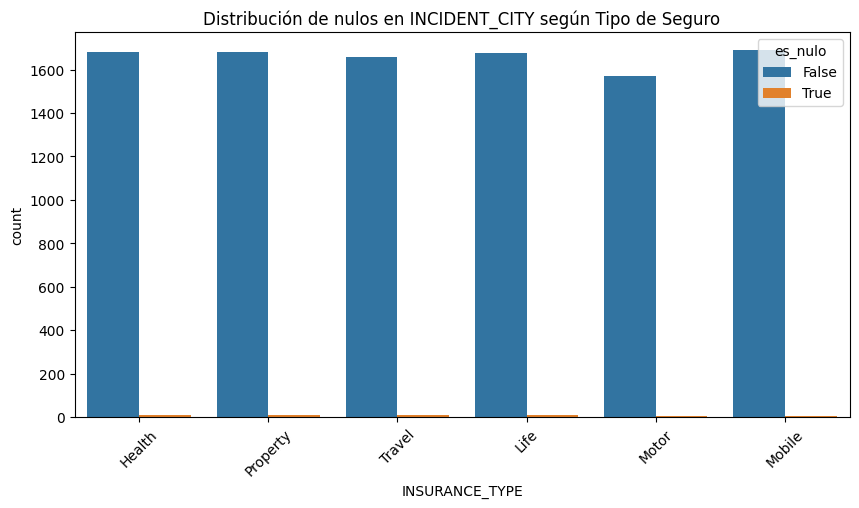

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos una columna auxiliar que indique si el dato es nulo
insurance_data['es_nulo'] = insurance_data['INCIDENT_CITY'].isnull()

# 2. Comparamos contra variables clave (ejemplo: INSURANCE_TYPE)
plt.figure(figsize=(10, 5))
sns.countplot(data=insurance_data, x='INSURANCE_TYPE', hue='es_nulo')
plt.title('Distribución de nulos en INCIDENT_CITY según Tipo de Seguro')
plt.xticks(rotation=45)
plt.show()

**Insights**

Los nulos en `INCIDENT_CITY` datos son MCAR (Missing Completely at Random). No existe una inclinación o tendencia hacia un tipo de seguro específico. El hecho de que falte el dato de la ciudad del incidente (INCIDENT_CITY) parece ser un error de registro totalmente aleatorio, distribuido de forma uniforme entre todos los tipos de seguro.
Decidimos no eliminar estas filas con nulos y separar la info del missing, de la imputación. Para no introducir solamente una nueva categoría "Unknown" que puede distorsionar el modelo, ya que es una variable relacionada al siniestro, puede tener impacto en fraude, el missing puede ser informativo.

In [21]:
# 1. Crear flag
insurance_data["INCIDENT_CITY_MISSING"] = insurance_data["INCIDENT_CITY"].isna().astype(int)

# 2. Imputar
insurance_data["INCIDENT_CITY"] = insurance_data.groupby("INCIDENT_STATE")["INCIDENT_CITY"]\
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

**Insights**

- `CUSTOMER_EDUCATION_LEVEL`: 5.3% nulos. Variable demográfica / socioeconómica del cliente. Los nulos acá significan:
    - “No sabemos el nivel educativo del cliente”.
    - No significa: “no tiene educación”, “no aplica”.
    Podemos:
    - imputar con moda (puede introducir sesgo)
    - eliminar filas (pérdida innecesaria de datos)
    - ignorarlo (modelos pueden fallar con NaNs)
    - imputarlos con "Unknown". **Acción elegida**

In [22]:
insurance_data["CUSTOMER_EDUCATION_LEVEL"] = (
    insurance_data["CUSTOMER_EDUCATION_LEVEL"]
    .fillna("Unknown")
)

In [23]:
insurance_data.groupby("CUSTOMER_EDUCATION_LEVEL")["CLAIM_AMOUNT"].mean()

CUSTOMER_EDUCATION_LEVEL
Bachelor       16934.652969
College        17022.705314
High School    16855.136268
MD             15196.103896
Masters        15389.952153
PhD            17089.915966
Unknown        14794.139887
Name: CLAIM_AMOUNT, dtype: float64

**Insights**

"Unknown" en `CUSTOMER_EDUCATION_LEVEL`. Tiene el menor monto promedio de reclamo. Sí aporta información y por lo tanto no conviene eliminarlo.

In [24]:
analizar_nulos(insurance_data, "Insurance Data")

--- Análisis de Nulos: Insurance Data ---
¡Excelente! No hay valores nulos en este DataFrame.
-----------------------------------



**Vemos ahora que la tabla insurance_data no tiene nulos (todos los nulos fueron tratados)**

#### Tipos de datos incorrectos

Todavía no analizamos los duplicados que nos permiten unir correctamente las tres tablas. Por lo que el análisis de tipos lo haremos sobre las 3 tablas.

**Tipos de datos incorrectos en `employees_data`**

In [26]:
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   AGENT_ID            1200 non-null   object
 1   AGENT_NAME          1200 non-null   object
 2   DATE_OF_JOINING     1200 non-null   object
 3   ADDRESS_LINE1       1200 non-null   object
 4   CITY                1200 non-null   object
 5   STATE               1200 non-null   object
 6   POSTAL_CODE         1200 non-null   int64 
 7   EMP_ROUTING_NUMBER  1200 non-null   int64 
 8   EMP_ACCT_NUMBER     1200 non-null   object
dtypes: int64(2), object(7)
memory usage: 84.5+ KB


**Insights**

- `DATE_OF_JOINING`: object. Debería ser fecha (fecha en la que el agente de seguros se incorporó a la empresa).
- `POSTAL_CODE`: int64. Debería ser string. Es un código, no un número.
- `EMP_ROUTING_NUMBER`: int64, identificador de banco/sucursal para transferencias, NO es una variable numérica real. Aunque esté como int64, en realidad es un identificador, sin significado ordinal, sin relación matemática. Debería ser string (o eliminarla dado que no aporta valor analítico al problema y representa información sensible). Por el momento la transformamos a string.

In [30]:
employee_data["DATE_OF_JOINING"] = pd.to_datetime(
    employee_data["DATE_OF_JOINING"],
    errors="coerce"
)

employee_data["POSTAL_CODE"] = employee_data["POSTAL_CODE"].astype(str)

employee_data["EMP_ROUTING_NUMBER"] = employee_data["EMP_ROUTING_NUMBER"].astype(str)

**Tipos de datos incorrectos en `vendor_data`**

In [31]:
vendor_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   VENDOR_ID      600 non-null    object
 1   VENDOR_NAME    600 non-null    object
 2   ADDRESS_LINE1  600 non-null    object
 3   CITY           600 non-null    object
 4   STATE          600 non-null    object
 5   POSTAL_CODE    600 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 28.3+ KB


**Insights**

- La mayoría de los tipos están correctos en esta tabla.
- `POSTAL_CODE`: int64. Debería ser string. Es un código, no un número.


In [33]:
vendor_data["POSTAL_CODE"] = vendor_data["POSTAL_CODE"].astype(str)

**Tipos de datos incorrectos en `insurance_data`**

In [34]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TXN_DATE_TIME             10000 non-null  object 
 1   TRANSACTION_ID            10000 non-null  object 
 2   CUSTOMER_ID               10000 non-null  object 
 3   POLICY_NUMBER             10000 non-null  object 
 4   POLICY_EFF_DT             10000 non-null  object 
 5   LOSS_DT                   10000 non-null  object 
 6   REPORT_DT                 10000 non-null  object 
 7   INSURANCE_TYPE            10000 non-null  object 
 8   PREMIUM_AMOUNT            10000 non-null  float64
 9   CLAIM_AMOUNT              10000 non-null  int64  
 10  CUSTOMER_NAME             10000 non-null  object 
 11  ADDRESS_LINE1             10000 non-null  object 
 12  CITY                      10000 non-null  object 
 13  STATE                     10000 non-null  object 
 14  POSTAL_

**Insights**

- Variables de fecha mal tipadas, están como object pero representan fechas.
    - TXN_DATE_TIME (Cuándo se registró la transacción o siniestro en el sistema. Puede haber muchas por cada siniestro, actualizaciones, pagos, ajustes.)
    - POLICY_EFF_DT (Es la fecha en la que la póliza de seguro entra en vigor. Es el momento desde el cual el cliente tiene cobertura legal)
    - LOSS_DT (Es la fecha real en la que ocurrió el incidente que causó la pérdida - el accidente, el robo, el daño-)
    - REPORT_DT (Es la fecha en que el cliente notificó formalmente a la aseguradora que ocurrió el incidente. Normalmente hay una sola por cada siniestro.)
- POSTAL_CODE: debería ser string.
- Variables numéricas binarias, están como int64, las pasamos a int8 para ocupar menos memoria:
    - ANY_INJURY
    - POLICE_REPORT_AVAILABLE
- El resto de las variables están bien tipadas.





In [38]:
# Pasamos las fechas de 'object' a 'datetime'
cols_fecha = ["TXN_DATE_TIME", "POLICY_EFF_DT", "LOSS_DT", "REPORT_DT"]

for col in cols_fecha:
    if col in insurance_data.columns:
        insurance_data[col] = pd.to_datetime(
            insurance_data[col],
            errors="coerce"  # convierte errores a NaT
        )
display(pd.DataFrame({
    "columna": cols_fecha,
    "tipo": insurance_data[cols_fecha].dtypes.values
}))
for col in cols_fecha:
    print(f"{col}: {insurance_data[col].isna().sum()} valores NaT")

,columna,tipo
0,TXN_DATE_TIME,datetime64[ns]
1,POLICY_EFF_DT,datetime64[ns]
2,LOSS_DT,datetime64[ns]
3,REPORT_DT,datetime64[ns]


TXN_DATE_TIME: 0 valores NaT
POLICY_EFF_DT: 0 valores NaT
LOSS_DT: 0 valores NaT
REPORT_DT: 0 valores NaT


No hay fechas que no se puedieran convertir por estar mal formateadas.

In [ ]:
# POSTAL_CODE A string
insurance_data["POSTAL_CODE"] = insurance_data["POSTAL_CODE"].astype(str)

In [ ]:
# Variables binarias a int8
insurance_data["ANY_INJURY"] = insurance_data["ANY_INJURY"].astype("int8")
insurance_data["POLICE_REPORT_AVAILABLE"] = insurance_data["POLICE_REPORT_AVAILABLE"].astype("int8")
print(insurance_data.ANY_INJURY.unique(), insurance_data.POLICE_REPORT_AVAILABLE.unique())

[0 1] [1 0]


#### Outliers

Al análisis de outliers lo haremos sobre la tabla `insurance_data`.

Vamos a usar:

- IQR (Interquartile Range)
- Boxplots

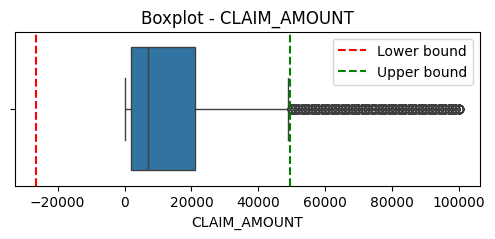

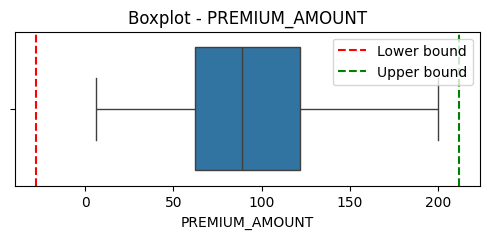

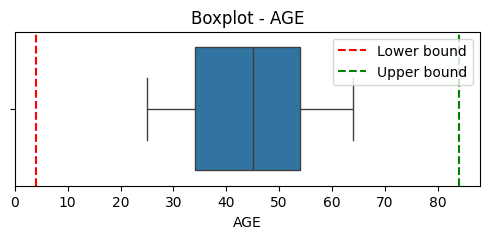

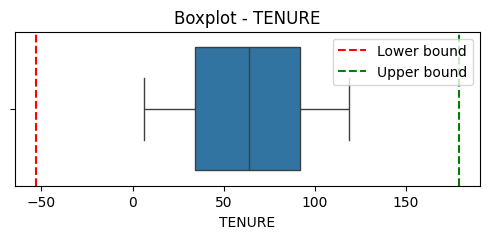

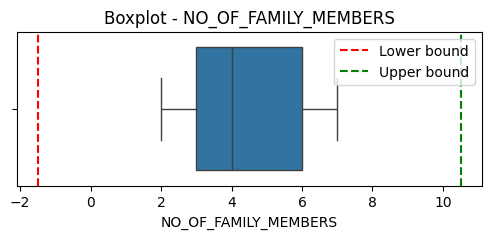

,columna,outliers,%_outliers,min,max
0,CLAIM_AMOUNT,920,9.2,100.0,100000.0
1,PREMIUM_AMOUNT,0,0.0,6.0,200.0
2,AGE,0,0.0,25.0,64.0
3,TENURE,0,0.0,6.0,119.0
4,NO_OF_FAMILY_MEMBERS,0,0.0,2.0,7.0


In [50]:
cols_insurance = [
    "CLAIM_AMOUNT",
    "PREMIUM_AMOUNT",
    "AGE",
    "TENURE",
    "NO_OF_FAMILY_MEMBERS"
]
detectar_outliers_iqr(insurance_data, cols_insurance, plot=True)

**Insights**

- `CLAIM_AMOUNT`: 9.2% outliers.
    - Distribución fuertemente sesgada a la derecha.
    - Muchos valores altos (hasta 100.000).
    - Límite superior ~55k (aprox por IQR).
    - Estos outliers NO son errores necesariamente. Pueden ser siniestros reales de alta severidad, casos extremos (ej: pérdida total), posibles fraudes.
    - En fraude, los outliers son señal, no ruido.
    - Aplicamos transformación logarítmica para reducir skew (asimetría en la distribución) sin perder información.
- El resto de las variables analizadas no presenta outliers significativos, por lo que no requieren tratamiento adicional.



In [51]:
insurance_data["CLAIM_AMOUNT_LOG"] = np.log1p(insurance_data["CLAIM_AMOUNT"])

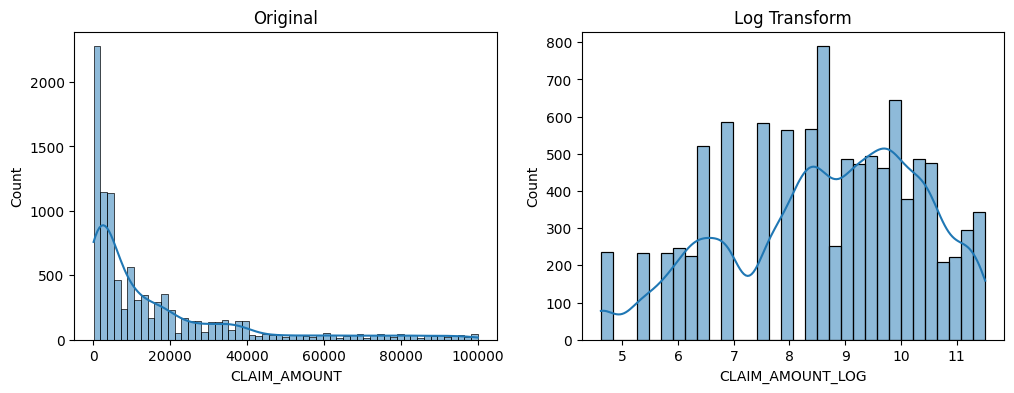

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(insurance_data["CLAIM_AMOUNT"], kde=True, ax=axes[0])
axes[0].set_title("Original")

sns.histplot(insurance_data["CLAIM_AMOUNT_LOG"], kde=True, ax=axes[1])
axes[1].set_title("Log Transform")

plt.show()

#### Inconsistencias: Duplicados

In [54]:
# Filas duplicadas completas

# insurance_data
print(insurance_data.duplicated().sum())

# employee_data
print(employee_data.duplicated().sum())

# vendor_data
print(vendor_data.duplicated().sum())

0
0
0


No hay filas duplicadas completas.

In [55]:
# Duplicados por ID en employee_data (AGENT_ID)
employee_data["AGENT_ID"].duplicated().sum()

0

In [57]:
# Duplicados por ID en vendor_data (VENDOR_ID)
print(vendor_data["VENDOR_ID"].duplicated().sum())
inconsistentes = (
    vendor_data
    .groupby("VENDOR_ID")
    .nunique()
)

inconsistentes[inconsistentes.max(axis=1) > 1]

0


,VENDOR_NAME,ADDRESS_LINE1,CITY,STATE,POSTAL_CODE
VENDOR_ID,,,,,


In [58]:
vendor_data["VENDOR_ID"].value_counts().head()

VENDOR_ID
VNDR00001    1
VNDR00395    1
VNDR00397    1
VNDR00398    1
VNDR00399    1
Name: count, dtype: int64

No hay mismos VENDOR_ID con diferentes nombres/direcciones

In [60]:
# Duplicados por ID en insurance_data (TRANSACTION_ID)
insurance_data["TRANSACTION_ID"].duplicated().sum()

0

In [61]:
cols_clave = ["CUSTOMER_ID", "POLICY_NUMBER", "LOSS_DT", "CLAIM_AMOUNT"]

insurance_data.duplicated(subset=cols_clave).sum()

0

In [ ]:
# VENDOR_ID que no existen en vendor_data
set(insurance_data["VENDOR_ID"]) - set(vendor_data["VENDOR_ID"])

{'No_Vendor'}

Valor categórico agregado a insurance_data cuando no había dato de `VENDOR_ID`. Crear flag explícito `HAS_VENDOR` como booleano.

In [64]:
insurance_data["HAS_VENDOR"] = (
    insurance_data["VENDOR_ID"] != "No_Vendor"
).astype(int)

#### Integración de los 3 datasets ya "limpios"

In [66]:
# =========================
# 1. COPIAS DE TRABAJO
# =========================

ins = insurance_data.copy()
emp = employee_data.copy()
ven = vendor_data.copy()


# =========================
# 2. VALIDAR UNICIDAD DE DIMENSIONES
# =========================

print("Duplicados AGENT_ID en employee_data:", emp["AGENT_ID"].duplicated().sum())
print("Duplicados VENDOR_ID en vendor_data:", ven["VENDOR_ID"].duplicated().sum())

assert emp["AGENT_ID"].is_unique, "ERROR: AGENT_ID no es único en employee_data"
assert ven["VENDOR_ID"].is_unique, "ERROR: VENDOR_ID no es único en vendor_data"


# =========================
# 3. VALIDAR INTEGRIDAD REFERENCIAL
# =========================

agent_ids_faltantes = set(ins["AGENT_ID"]) - set(emp["AGENT_ID"])
vendor_ids_faltantes = set(ins["VENDOR_ID"]) - set(ven["VENDOR_ID"])

# Como 'No_Vendor' es una categoría creada, no se considera error
vendor_ids_faltantes_reales = vendor_ids_faltantes - {"No_Vendor"}

print("AGENT_ID en insurance_data que no existen en employee_data:")
print(agent_ids_faltantes)

print("\nVENDOR_ID reales en insurance_data que no existen en vendor_data:")
print(vendor_ids_faltantes_reales)

assert len(agent_ids_faltantes) == 0, "ERROR: hay AGENT_ID sin match en employee_data"
assert len(vendor_ids_faltantes_reales) == 0, "ERROR: hay VENDOR_ID reales sin match en vendor_data"


# =========================
# 4. RENOMBRAR COLUMNAS PARA EVITAR COLISIONES
# =========================

emp_renamed = emp.rename(columns={
    "AGENT_NAME": "AGENT_NAME",
    "DATE_OF_JOINING": "AGENT_DATE_OF_JOINING",
    "ADDRESS_LINE1": "AGENT_ADDRESS_LINE1",
    "CITY": "AGENT_CITY",
    "STATE": "AGENT_STATE",
    "POSTAL_CODE": "AGENT_POSTAL_CODE",
    "EMP_ROUTING_NUMBER": "AGENT_ROUTING_NUMBER",
    "EMP_ACCT_NUMBER": "AGENT_ACCT_NUMBER"
})

ven_renamed = ven.rename(columns={
    "VENDOR_NAME": "VENDOR_NAME",
    "ADDRESS_LINE1": "VENDOR_ADDRESS_LINE1",
    "CITY": "VENDOR_CITY",
    "STATE": "VENDOR_STATE",
    "POSTAL_CODE": "VENDOR_POSTAL_CODE"
})


# =========================
# 5. JOIN CON EMPLOYEE_DATA
# =========================

df_model = ins.merge(
    emp_renamed,
    on="AGENT_ID",
    how="left",
    validate="many_to_one"
)


# =========================
# 6. JOIN CON VENDOR_DATA
# =========================

df_model = df_model.merge(
    ven_renamed,
    on="VENDOR_ID",
    how="left",
    validate="many_to_one"
)


# =========================
# 7. VALIDACIONES POST-JOIN
# =========================

print("Filas insurance_data:", ins.shape[0])
print("Filas df_model:", df_model.shape[0])

assert df_model.shape[0] == ins.shape[0], "ERROR: el join cambió la cantidad de filas"

print("\nNulos post-join en campos de agente:")
print(df_model[["AGENT_NAME", "AGENT_DATE_OF_JOINING"]].isna().sum())

print("\nNulos post-join en campos de proveedor:")
print(df_model[["VENDOR_NAME", "VENDOR_CITY"]].isna().sum())


# =========================
# 8. FLAG DE PROVEEDOR
# =========================

df_model["HAS_VENDOR"] = (df_model["VENDOR_ID"] != "No_Vendor").astype("int8")


# =========================
# 9. RESULTADO FINAL
# =========================

print("\nShape final:", df_model.shape)
df_model.head()

Duplicados AGENT_ID en employee_data: 0
Duplicados VENDOR_ID en vendor_data: 0
AGENT_ID en insurance_data que no existen en employee_data:
set()

VENDOR_ID reales en insurance_data que no existen en vendor_data:
set()
Filas insurance_data: 10000
Filas df_model: 10000

Nulos post-join en campos de agente:
AGENT_NAME               0
AGENT_DATE_OF_JOINING    0
dtype: int64

Nulos post-join en campos de proveedor:
VENDOR_NAME    3245
VENDOR_CITY    3245
dtype: int64

Shape final: (10000, 54)


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,AGENT_CITY,AGENT_STATE,AGENT_POSTAL_CODE,AGENT_ROUTING_NUMBER,AGENT_ACCT_NUMBER,VENDOR_NAME,VENDOR_ADDRESS_LINE1,VENDOR_CITY,VENDOR_STATE,VENDOR_POSTAL_CODE
0,2020-06-01,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,...,Nashville,TN,37217,35441155,LRZO53254369804934,Ramsey Inc,3114 West 20th Court,Panama City,FL,32405
1,2020-06-01,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,...,Glendale,AZ,85301,44055451,XBYG14382904542874,"Morales, Campbell and Washington",42 West Louise Street,Fayetteville,AR,72701
2,2020-06-01,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,...,Montgomery,AL,36105,55770246,WRXH14597428306333,Johnson Ltd,2619 North Quality Lane,Fayetteville,AR,72703
3,2020-06-01,TXN00000004,A00007572,PLC00009292,2016-11-29,2020-05-14,2020-05-19,Health,172.87,16000,...,Norman,OK,73071,87652976,YEPN16077902472499,Blackwell-Foster,3609 Meadow Drive,Nashville,TN,37215
4,2020-06-01,TXN00000005,A00008173,PLC00000204,2011-12-26,2020-05-17,2020-05-22,Travel,88.53,3000,...,Glen Burnie,MD,21061,76119019,HZBK86544578578547,Evans-Scott,4001 19th Place Northeast,Washington,DC,20018


Nulos post-join en proveedor: 3245. Esto coincide con los casos "No_Vendor". No es error: son siniestros sin proveedor asociado.

### 1.3 Calculá al menos **dos features derivadas temporales**, por ejemplo:
  - días entre `LOSS_DT` y `REPORT_DT`  
  - antigüedad de la póliza al momento del siniestro

**Días entre `LOSS_DT` y `REPORT_DT`**

Variable CLAVE para fraude, al medir el lapso entre el incidente y la notificación, estamos cuantificando el "tiempo de preparación" del cliente.

- delays largos: sospechoso ("Montaje" del siniestro, presentar daños preexistentes)
- reportes inmediatos: más confiables (Preservación de la evidencia, Menor tiempo de manipulación)

In [72]:
df_model["REPORT_DELAY_DAYS"] = (
    df_model["REPORT_DT"] - df_model["LOSS_DT"]
).dt.days

In [75]:
df_model["REPORT_DELAY_DAYS"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

count    10000.000000
mean         3.211800
std          1.966908
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
90%          5.000000
max          5.000000
Name: REPORT_DELAY_DAYS, dtype: float64

In [ ]:
# Podríamos agregar la siguiente categorización, aunque el delay de reporte es MUY corto en todos los casos (<5)
bins = [-1, 0, 1, 3, 5]
labels = [
    "Inmediato",   # 0 días
    "Muy_Rapido",  # 1 día
    "Normal",      # 2-3 días
    "Tardio"       # 4-5 días
]

df_model["DELAY_CATEGORY"] = pd.cut(
    df_model["REPORT_DELAY_DAYS"],
    bins=bins,
    labels=labels
)

# Cuenta cuántas transacciones hay en cada categoría de retraso
print(df_model['DELAY_CATEGORY'].value_counts())

DELAY_CATEGORY
Tardio        4959
Normal        2423
Inmediato     1565
Muy_Rapido    1053
Name: count, dtype: int64


**Calcular antigüedad de la póliza**

Fraude típico: reclamos poco después de contratar.


In [ ]:
df_model["POLICY_AGE_DAYS"] = (
    df_model["LOSS_DT"] - df_model["POLICY_EFF_DT"]
).dt.days
print(df_model['DELAY_CATEGORY'].value_counts())

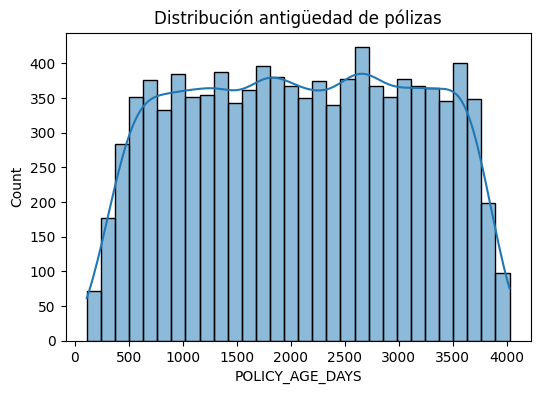

In [79]:
plt.figure(figsize=(6,4))
sns.histplot(df_model["POLICY_AGE_DAYS"], bins=30, kde=True)
plt.title("Distribución antigüedad de pólizas")
plt.show()

In [81]:
df_model["POLICY_AGE_DAYS"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

count    10000.000000
mean      2096.476800
std       1029.518847
min        110.000000
25%       1219.000000
50%       2096.000000
75%       2981.000000
90%       3519.000000
max       4026.000000
Name: POLICY_AGE_DAYS, dtype: float64

In [ ]:
# Transformamos la antigüedad a años
df_model["POLICY_AGE_YEARS"] = df_model["POLICY_AGE_DAYS"] / 365
df_model["POLICY_AGE_YEARS"].describe()

count    10000.000000
mean         5.743772
std          2.820600
min          0.301370
25%          3.339726
50%          5.742466
75%          8.167123
max         11.030137
Name: POLICY_AGE_YEARS, dtype: float64

In [ ]:
# Creamos bins categóricos por antigüedad de la póliza
def crear_bins_policy_age(df):
    bins = [
        0,
        1219,   # Q1
        2096,   # mediana
        2981,   # Q3
        3519,   # P90
        df["POLICY_AGE_DAYS"].max()
    ]

    labels = [
        "Relativamente_Nueva",   # < Q1
        "Media_Baja",           # Q1 - median
        "Media_Alta",           # median - Q3
        "Antigua",              # Q3 - P90
        "Muy_Antigua"           # > P90
    ]

    df["POLICY_AGE_CAT"] = pd.cut(
        df["POLICY_AGE_DAYS"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    return df

df_model = crear_bins_policy_age(df_model)

In [ ]:
# Relación entre antigüedad de la póliza y monto reclamado
df_model.groupby("POLICY_AGE_CAT")["CLAIM_AMOUNT"].mean()

C:\Users\ithre\AppData\Local\Temp\ipykernel_22632\4105141055.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby("POLICY_AGE_CAT")["CLAIM_AMOUNT"].mean()


POLICY_AGE_CAT
Relativamente_Nueva    16964.254298
Media_Baja             15752.160000
Media_Alta             17168.440000
Antigua                16375.866667
Muy_Antigua            16361.761762
Name: CLAIM_AMOUNT, dtype: float64

**Tiempo desde inicio de póliza hasta reporte**

Detecta: reclamos “tempranos” tras contratar.

In [89]:
df_model["TIME_TO_REPORT_FROM_POLICY"] = (
    df_model["REPORT_DT"] - df_model["POLICY_EFF_DT"]
).dt.days

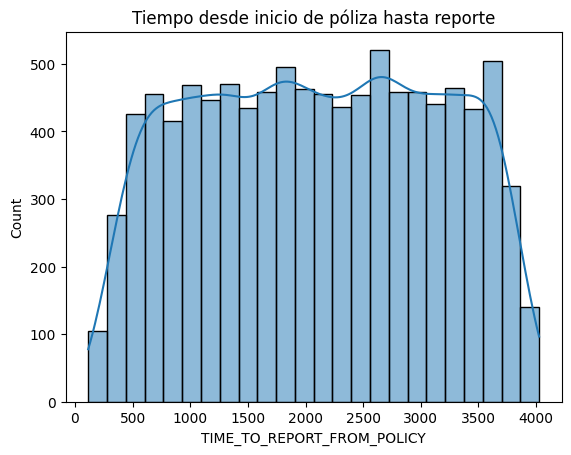

In [90]:
sns.histplot(df_model["TIME_TO_REPORT_FROM_POLICY"], kde=True)
plt.title("Tiempo desde inicio de póliza hasta reporte")
plt.show()

**Tiempo entre evento y registro del sistema**

In [91]:
df_model["TXN_DELAY_DAYS"] = (
    df_model["TXN_DATE_TIME"] - df_model["LOSS_DT"]
).dt.days

In [92]:
df_model["TXN_DELAY_DAYS"].describe(percentiles=[0.25,0.5,0.75,0.9])

count    10000.000000
mean        10.420100
std          5.835171
min          1.000000
25%          5.000000
50%         10.000000
75%         16.000000
90%         19.000000
max         20.000000
Name: TXN_DELAY_DAYS, dtype: float64

In [93]:
# Esto indica: fechas mal cargadas, desorden temporal
df_model[df_model["TXN_DELAY_DAYS"] < 0]

,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,...,VENDOR_CITY,VENDOR_STATE,VENDOR_POSTAL_CODE,POLICY_AGE_DAYS,REPORT_DELAY_DAYS,DELAY_CATEGORY,POLICY_AGE_YEARS,POLICY_AGE_CAT,TIME_TO_REPORT_FROM_POLICY,TXN_DELAY_DAYS


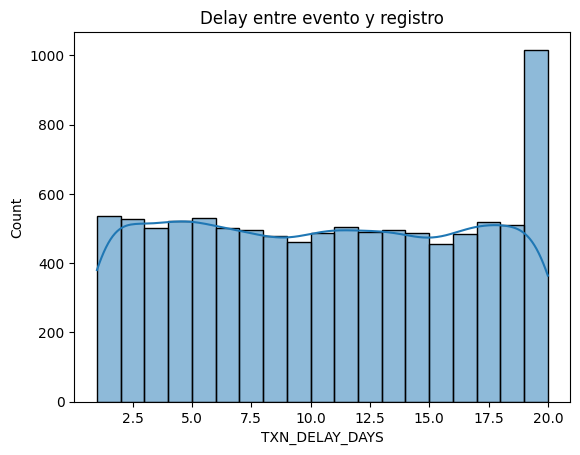

In [94]:
sns.histplot(df_model["TXN_DELAY_DAYS"], kde=True)
plt.title("Delay entre evento y registro")
plt.show()

**Features de calendario**

In [96]:
df_model["LOSS_DAY_OF_WEEK"] = df_model["LOSS_DT"].dt.dayofweek
df_model["IS_WEEKEND"] = df_model["LOSS_DAY_OF_WEEK"].isin([5,6]).astype("int8")
df_model["LOSS_MONTH"] = df_model["LOSS_DT"].dt.month

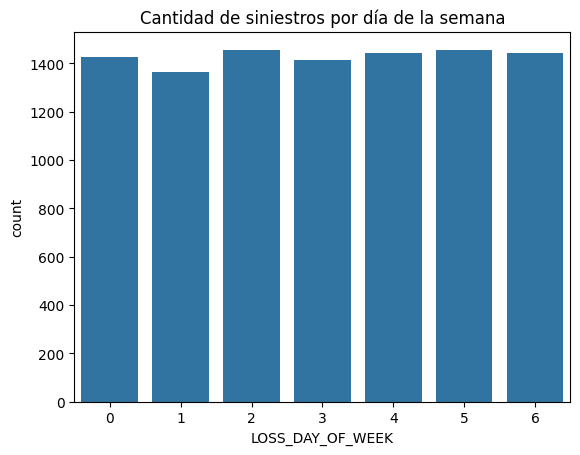

In [97]:
sns.countplot(x="LOSS_DAY_OF_WEEK", data=df_model)
plt.title("Cantidad de siniestros por día de la semana")
plt.show()

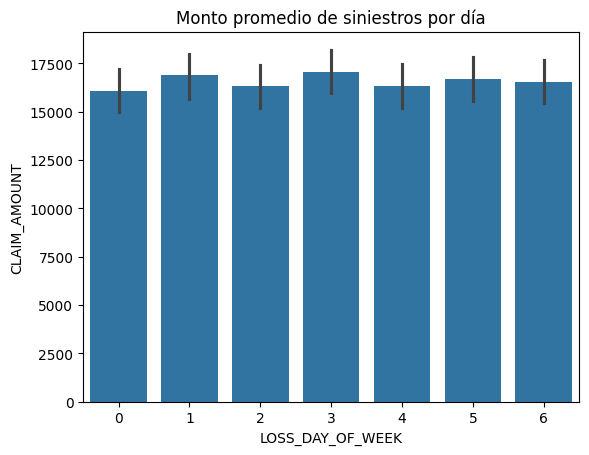

In [98]:
sns.barplot(
    x="LOSS_DAY_OF_WEEK",
    y="CLAIM_AMOUNT",
    data=df_model,
    estimator="mean"
)
plt.title("Monto promedio de siniestros por día")
plt.show()

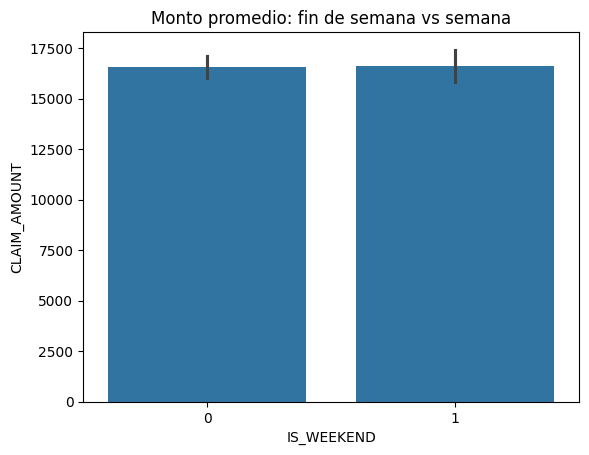

In [99]:
sns.barplot(
    x="IS_WEEKEND",
    y="CLAIM_AMOUNT",
    data=df_model
)
plt.title("Monto promedio: fin de semana vs semana")
plt.show()

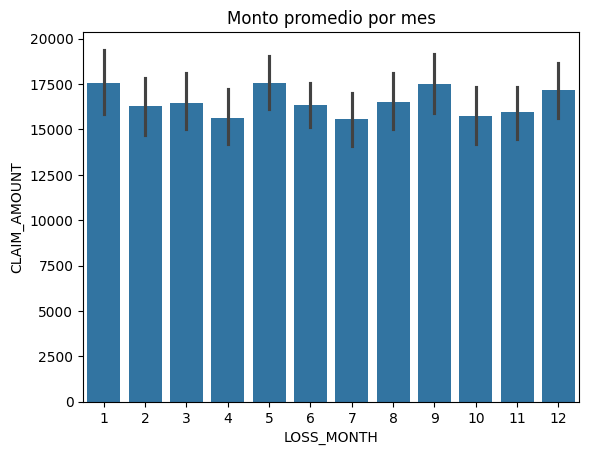

In [100]:
sns.barplot(
    x="LOSS_MONTH",
    y="CLAIM_AMOUNT",
    data=df_model,
    estimator="mean"
)
plt.title("Monto promedio por mes")
plt.show()

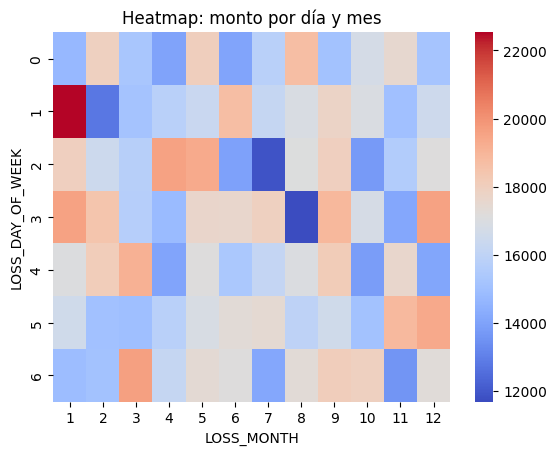

In [103]:
pivot = df_model.pivot_table(
    values="CLAIM_AMOUNT",
    index="LOSS_DAY_OF_WEEK",
    columns="LOSS_MONTH",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="coolwarm")
plt.title("Heatmap: monto por día y mes")
plt.show()

**Insights**

- NO hay diferencias fuertes en el delay en informar el siniestro y cuándo ocurrió, todos los valores están entre ~15.7k y ~17.1k, la antigüedad de la póliza no discrimina bien el monto.
- La antigüedad de las pólizas está bien distribuida:
    - no hay concentración en valores bajos (No hay evidencia de “pólizas recién creadas”)
    - no hay predominancia de pólizas nuevas
    - no hay outliers extremos
    - N hay skew
    - No hay clusters claros
    - Esto explica por qué no vimos diferencias en CLAIM_AMOUNT
- En el tiempo desde inicio de póliza hasta reporte:
    - distribución bastante uniforme
    - sin picos marcados
    - sin concentración en valores bajos
    - rango amplio (~100 a 4000 días)
    - No hay evidencia de reclamos tempranos
-  Delay entre el evento y registro en el sistema:
    - rango acotado: 1 a 20 días
    - bastante uniforme, sin outliers, sin skew
    - TXN_DELAY_DAYS no tiene señal fuerte
- TODAS las variables temporales (calendario) muestran:
    - distribución uniforme
    - baja variabilidad
    - ausencia de patrones fuertes

**Las variables temporales analizadas no presentan patrones significativos ni en frecuencia ni en severidad (qué tan grave / costoso es el siniestro), lo que sugiere que el comportamiento de los siniestros es independiente del momento temporal en este dataset.**

## 2. Analytics de Negocio (35%)

• Escribí 2 insights accionables: qué encontraste, qué dato lo respalda y qué acción
recomendarías.

• (Opcional pero valorado) Construí un modelo predictivo o clasificatorio simple — por ejemplo:
predecir CLAIM_STATUS, el monto del claim, o si un siniestro es de alto riesgo. No importa la complejidad del modelo: lo que evaluamos es la selección de features, la interpretación del resultado y qué tan bien podés explicar qué aprendió el modelo.

### 2.1 KPIs

Definí 3 KPIs relevantes para monitorear siniestros, por ejemplo: tasa de rechazo por tipo de seguro, loss ratio (claim/premium), tiempo promedio de reporte. Calculalos y comentá qué dice cada uno.

**A - KPI: Tasa de rechazo por tipo de seguro**

In [104]:
# Ver valores de CLAIM_STATUS
df_model["CLAIM_STATUS"].value_counts()

CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64

A = Approved

D = Disapproved

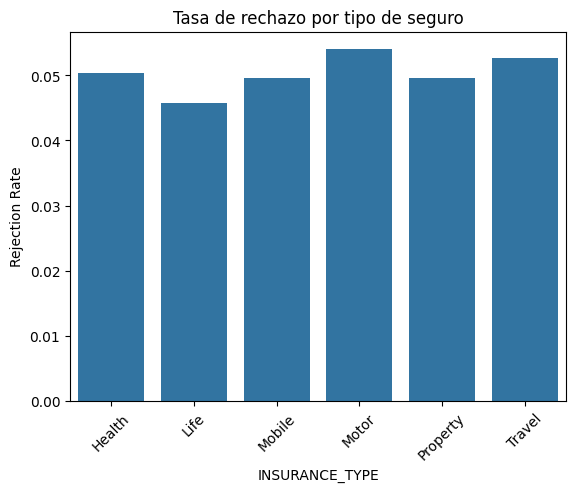

In [108]:
# Calcular tasa de rechazo
rechazo_por_tipo = pd.crosstab(
    df_model["INSURANCE_TYPE"],
    df_model["CLAIM_STATUS"],
    normalize="index"
)

rechazo_por_tipo["REJECTION_RATE"] = rechazo_por_tipo.get("D", 0)

rechazo_plot = rechazo_por_tipo.reset_index()

sns.barplot(
    x="INSURANCE_TYPE",
    y="REJECTION_RATE",
    data=rechazo_plot
)

plt.title("Tasa de rechazo por tipo de seguro")
plt.ylabel("Rejection Rate")
plt.xticks(rotation=45)
plt.show()

In [109]:
# Cruzarlo con monto, dice si rechazan más los reclamos altos
df_model.groupby(["INSURANCE_TYPE", "CLAIM_STATUS"])["CLAIM_AMOUNT"].mean()

INSURANCE_TYPE  CLAIM_STATUS
Health          A               10808.099688
                D               10670.588235
Life            A               54090.342679
                D               60558.441558
Mobile          A                 407.027363
                D                 402.380952
Motor           A                5493.619879
                D                5682.352941
Property        A               24536.069652
                D               25297.619048
Travel          A                2991.150442
                D                2772.727273
Name: CLAIM_AMOUNT, dtype: float64

**Insights**

- Se analizó la proporción de siniestros rechazados por tipo de seguro, observándose una distribución homogénea entre los distintos productos, con tasas cercanas al 5%.

- Esto sugiere que no existen diferencias significativas en el nivel de rechazo entre tipos de seguro.

- Sin embargo, al analizar el monto promedio de los siniestros según su estado (aprobado vs rechazado), se identificó un patrón relevante en seguros de vida (Life), donde los siniestros rechazados presentan un monto promedio superior a los aprobados.

- Este comportamiento podría indicar un mayor control o filtrado sobre reclamos de alto valor en este segmento, lo cual es consistente con estrategias de mitigación de riesgo o detección de fraude.

**B - KPI: Loss ratio (claim/premium)**

Permite medir cuánto paga la aseguradora por cada unidad de ingreso, siendo un indicador clave de rentabilidad y riesgo.

| Loss Ratio | Qué significa |
| ---------- | ------------- |
| < 1        | gana dinero   |
| = 1        | empata        |
| > 1        | pierde dinero |


In [112]:
# Definición
df_model["LOSS_RATIO"] = df_model["CLAIM_AMOUNT"] / df_model["PREMIUM_AMOUNT"]

# Panorama general
print((df_model["LOSS_RATIO"] > 1).mean())
df_model["LOSS_RATIO"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

1.0


count    10000.000000
mean       199.259363
std        306.041819
min          5.013788
50%         74.461604
75%        194.753821
90%        609.441801
95%        964.403582
99%       1415.028210
max       1862.544235
Name: LOSS_RATIO, dtype: float64

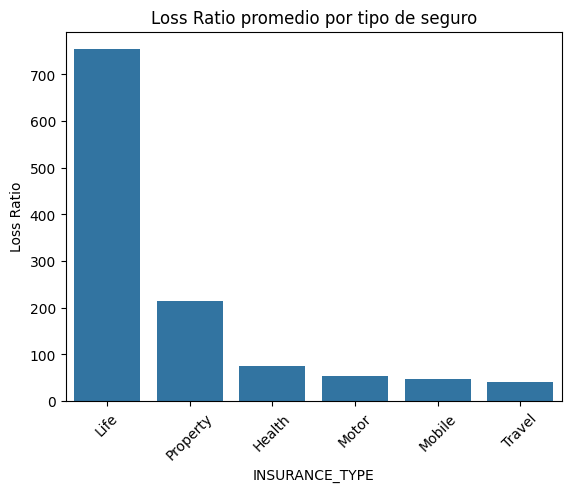

In [115]:
# Por tipo de seguro
# >1: producto deficitario
# ≈1: break-even (punto de equilibrio)
# <1: rentable
lr_by_type = df_model.groupby("INSURANCE_TYPE")["LOSS_RATIO"].mean().sort_values(ascending=False)
sns.barplot(x=lr_by_type.index, y=lr_by_type.values)
plt.xticks(rotation=45)
plt.title("Loss Ratio promedio por tipo de seguro")
plt.ylabel("Loss Ratio")
plt.show()


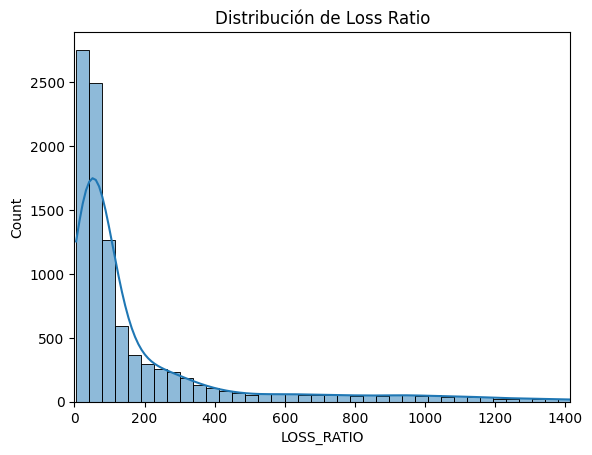

In [116]:
# Distribución (detectar riesgo real)
sns.histplot(df_model["LOSS_RATIO"], bins=50, kde=True)
plt.xlim(0, df_model["LOSS_RATIO"].quantile(0.99))  # cortar cola para ver forma
plt.title("Distribución de Loss Ratio")
plt.show()

In [117]:
top_lr = df_model.sort_values("LOSS_RATIO", ascending=False).head(20)
top_lr[["INSURANCE_TYPE", "CLAIM_AMOUNT", "PREMIUM_AMOUNT", "LOSS_RATIO"]]

,INSURANCE_TYPE,CLAIM_AMOUNT,PREMIUM_AMOUNT,LOSS_RATIO
6896,Life,100000,53.69,1862.544235
5512,Life,96000,52.65,1823.361823
4640,Life,100000,55.32,1807.664497
1350,Life,91000,50.53,1800.910350
8113,Life,99000,55.08,1797.385621
8914,Life,91000,50.91,1787.468081
4301,Life,93000,52.06,1786.400307
5932,Life,98000,55.13,1777.616543
7499,Life,90000,50.70,1775.147929
7271,Life,94000,53.07,1771.245525


In [118]:
# Por estado del claim
df_model.groupby("CLAIM_STATUS")["LOSS_RATIO"].mean()

CLAIM_STATUS
A    199.234382
D    199.731010
Name: LOSS_RATIO, dtype: float64

In [119]:
# Por severidad
df_model.groupby("INCIDENT_SEVERITY")["LOSS_RATIO"].mean()

INCIDENT_SEVERITY
Major Loss    201.447512
Minor Loss    194.664424
Total Loss    201.581794
Name: LOSS_RATIO, dtype: float64

In [120]:
# Por tipo + estado
df_model.groupby(["INSURANCE_TYPE","CLAIM_STATUS"])["LOSS_RATIO"].mean()

INSURANCE_TYPE  CLAIM_STATUS
Health          A                75.281761
                D                76.180461
Life            A               750.199585
                D               833.419939
Mobile          A                46.989974
                D                46.756127
Motor           A                54.541423
                D                56.773646
Property        A               214.165394
                D               210.147669
Travel          A                41.770769
                D                38.753919
Name: LOSS_RATIO, dtype: float64

In [ ]:
# Segmentación
bins = [0, 1, 3, 10, 50, 1e9]
labels = ["Rentable", "Alto", "Muy_Alto", "Crítico", "Extremo"]

df_model["LR_SEGMENT"] = pd.cut(df_model["LOSS_RATIO"], bins=bins, labels=labels)

df_model["LR_SEGMENT"].value_counts(normalize=True)

LR_SEGMENT
Extremo     0.6678
Crítico     0.3086
Muy_Alto    0.0236
Rentable    0.0000
Alto        0.0000
Name: proportion, dtype: float64

In [122]:
# agregar versión robusta
# Porque LOSS_RATIO tiene: cola muy larga (hasta ~1800), valores extremadamente grandes, distribución muy sesgada (skewed)
df_model["LOSS_RATIO_LOG"] = np.log1p(df_model["LOSS_RATIO"])

**Insights**

- El loss ratio presenta una distribución altamente sesgada, con una cola derecha pronunciada y valores extremos donde el monto del reclamo es significativamente mayor que la prima pagada.

- Se observa que el 100% de los casos presentan un loss ratio mayor a 1, lo cual indica que el dataset está compuesto exclusivamente por siniestros y no representa el comportamiento completo del portafolio.

- El análisis por tipo de seguro muestra que los seguros de vida concentran los mayores valores de loss ratio, siendo el principal driver de riesgo.

- No se observan diferencias significativas en el loss ratio entre siniestros aprobados y rechazados, lo que sugiere que los mecanismos de control no están discriminando efectivamente los casos de mayor impacto económico.

- Debido a la alta asimetría del loss ratio, se aplicó una transformación logarítmica (`log1p`) con el objetivo de reducir el impacto de valores extremos y mejorar la interpretabilidad de la variable. Esta transformación permite analizar patrones relativos entre observaciones sin que los casos extremos dominen el análisis.

**En conclusión, el loss ratio en este dataset es útil para identificar casos extremos y potenciales anomalías, pero no debe interpretarse como un indicador directo de rentabilidad del negocio.**

**C - KPI: Tasa de siniestros extremos** 

En vez de tiempo promedio de reporte (que ya vimos que no presenta variabilidad significativa ni capacidad discriminante en este dataset), se define un KPI alternativo centrado en el impacto económico.

Se considera como siniestro extremo aquellos casos con un loss ratio elevado, lo que permite identificar eventos donde el monto reclamado es desproporcionadamente alto respecto a la prima.

Este KPI resulta particularmente relevante para la detección de fraude y la gestión del riesgo, ya que los casos extremos suelen concentrar una parte significativa de las pérdidas.

In [ ]:
df_model["IS_EXTREME_LR"] = (df_model["LOSS_RATIO"] > 100).astype(int)
df_model["IS_EXTREME_LR"].mean()

0.3898

In [131]:
# Por tipo de seguro
# Ordenar el promedio de IS_EXTREME_LR descendente y convertir a porcentaje
(df_model.groupby("INSURANCE_TYPE")["IS_EXTREME_LR"].mean() * 100).round(2).sort_values(ascending=False)


INSURANCE_TYPE
Life        100.00
Property     90.07
Health       29.64
Motor         9.21
Mobile        2.72
Travel        0.00
Name: IS_EXTREME_LR, dtype: float64

**Insights**

- Se consideraron como siniestros extremos aquellos con un loss ratio mayor a 100.
- A nivel general, se observa que aproximadamente el 39% de los siniestros presentan características extremas, lo que indica una alta concentración de riesgo en el dataset.
- El análisis por tipo de seguro revela diferencias significativas, destacándose especialmente los seguros de vida (Life), donde el 100% de los siniestros son extremos, y los seguros de propiedad (Property), con más del 90%.
- Estos resultados sugieren problemas de pricing, segmentación de riesgo o posibles comportamientos anómalos en estos productos, siendo candidatos prioritarios para revisión y control.

**Se detectó que el riesgo no estaba en la frecuencia sino en la cola, por eso definí un KPI de siniestros extremos que reveló problemas claros en ciertos productos.**

### 2.2 Evolución mensual del volumen y monto de siniestros durante el período disponible

**Generación de la Tendencia Mensual**

Para analizar la evolución, utilizaremos la fecha de reporte (REPORT_DT), ya que es el momento en que la aseguradora toma conocimiento del pasivo e impacta operativamente.

Puede ser confuso interpretar a qué se refiere "volumen":

- Si se refiere a la cantidad de expedientes o reclamos que procesa la compañía, la variable clave es TRANSACTION_ID (count) => OPTAMOS POR ESTA DEFINICIÓN.
- Si se refiere al tamaño económico del reclamo (cuánto dinero está pidiendo el cliente), la variable es CLAIM_AMOUNT (se suma o promedia).

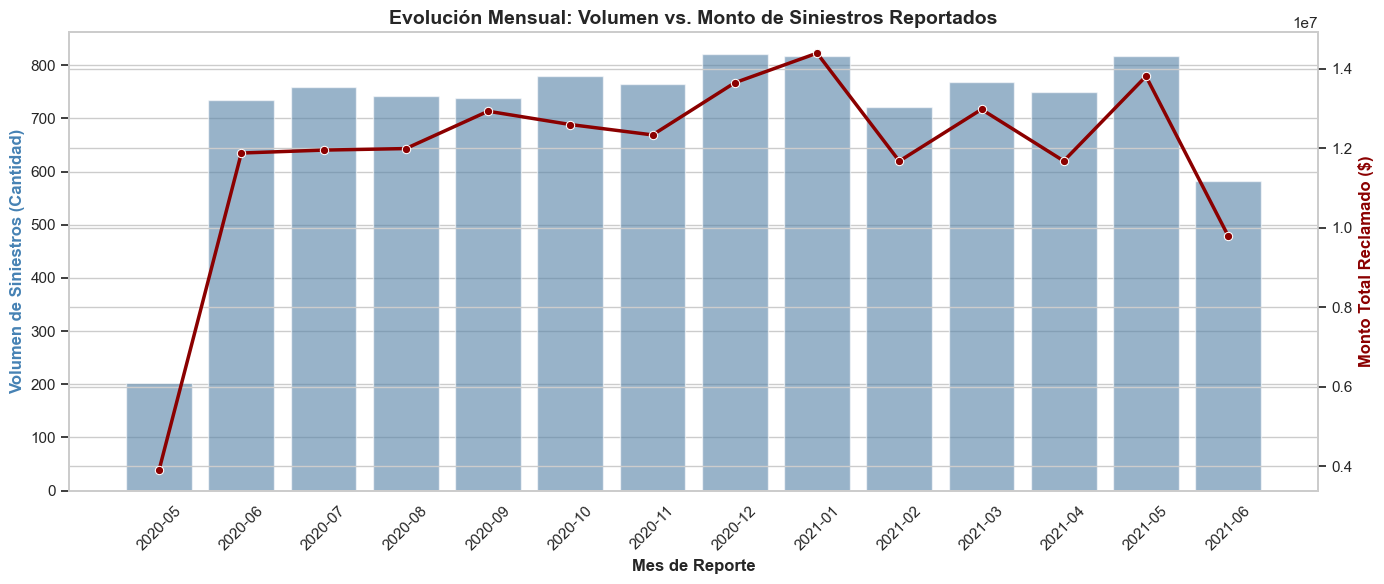

In [132]:
# 1. Asegurar que la fecha sea tipo datetime
df_model['REPORT_DT'] = pd.to_datetime(df_model['REPORT_DT'])

# 2. Crear una columna de "Año-Mes" para agrupar (ej. '2023-01')
df_model['ANIO_MES'] = df_model['REPORT_DT'].dt.to_period('M')

# 3. Agrupar para calcular Volumen (conteo) y Monto (suma)
evolucion_mensual = df_model.groupby('ANIO_MES').agg(
    VOLUMEN_SINIESTROS=('TRANSACTION_ID', 'count'),
    MONTO_TOTAL=('CLAIM_AMOUNT', 'sum')
).reset_index()

# Convertir 'ANIO_MES' a string para graficar correctamente
evolucion_mensual['ANIO_MES'] = evolucion_mensual['ANIO_MES'].astype(str)

# 4. Configurar estilo profesional (Seaborn)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Eje Izquierdo: Volumen (Barras) ---
sns.barplot(
    data=evolucion_mensual, 
    x='ANIO_MES', 
    y='VOLUMEN_SINIESTROS', 
    alpha=0.6, 
    color='steelblue', 
    ax=ax1
)
ax1.set_ylabel('Volumen de Siniestros (Cantidad)', color='steelblue', fontweight='bold')
ax1.set_xlabel('Mes de Reporte', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# --- Eje Derecho: Monto (Línea) ---
ax2 = ax1.twinx()
sns.lineplot(
    data=evolucion_mensual, 
    x='ANIO_MES', 
    y='MONTO_TOTAL', 
    color='darkred', 
    marker='o', 
    linewidth=2.5, 
    ax=ax2
)
ax2.set_ylabel('Monto Total Reclamado ($)', color='darkred', fontweight='bold')

# Título y ajustes finales
plt.title('Evolución Mensual: Volumen vs. Monto de Siniestros Reportados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observaciones Técnicas del Gráfico:**

- Eje Y primario (Barras Azules): Representa la carga operativa bruta (cuántos expedientes entraron).

- Eje Y secundario (Línea Roja): Representa el impacto financiero directo (cuánto dinero está en juego).

- Relación: Lo ideal es que ambas métricas se muevan en paralelo. Las divergencias (ej. pocos siniestros pero con picos históricos de monto) indican anomalías de severidad o "súper siniestros".

**Insights**

- Calidad de Datos: Los meses extremos (Mayo 2020 y Junio 2021) parecen tener datos incompletos. Acción: Excluirlos al calcular promedios mensuales o proyectar tendencias.
- Estabilidad Financiera: El monto total (línea) crece proporcionalmente a la cantidad de casos (barras). Conclusión: El costo promedio por siniestro es estable y predecible; no hay impacto de eventos catastróficos.
- Estacionalidad Operativa: Se detectan picos claros de demanda en Dic-Ene y en Mayo (>800 casos / ~$14.5M). Acción: Se recomienda reforzar equipos de atención al cliente y peritaje en esos meses para evitar cuellos de botella.
- Estrategia de Fraude: Al no haber anomalías de montos extremos, el riesgo se oculta en el volumen. Acción: Se recomienda enfocar las auditorías en detectar micro-fraudes cruzando los meses pico con métricas de comportamiento sospechoso (como reportes tardíos).

### 2.3 Identificá 2 anomalías o hallazgos en los datos, algo que no cierre o que parezca sospechoso.

Como vimos en los KPIs:


- **Hallazgo 1 — Desbalance económico extremo en el Loss Ratio**

- Evidencia:

    - La distribución del loss ratio presenta una fuerte asimetría hacia la derecha, con una cola larga que evidencia la presencia de valores extremos.
    - Se observa una alta concentración de casos en valores relativamente bajos, pero con numerosos siniestros que alcanzan valores muy elevados.
    - A partir del análisis cuantitativo:
        - 100% de los casos presentan LOSS_RATIO > 1
        - ~39% de los siniestros superan LOSS_RATIO > 100
        - Se identifican casos extremos donde:
            - PREMIUM ≈ 50 (lo que el cliente pagó por el seguro)
            - CLAIM ≈ 100.000 (lo que el cliente reclama tras el siniestro)
            - LOSS_RATIO ≈ 1800 (La aseguradora paga 1800 veces lo que cobró)

- ¿Por qué es sospechoso?

    En un negocio asegurador real, el loss ratio esperado suele estar cercano a 1 (o menor). La presencia sistemática de valores superiores a este umbral, junto con una proporción significativa de casos extremos, indica:

    - un fuerte desbalance entre prima y riesgo asumido
    - posibles problemas de pricing o segmentación
    - o un dataset sesgado, compuesto únicamente por siniestros sin considerar la cartera completa

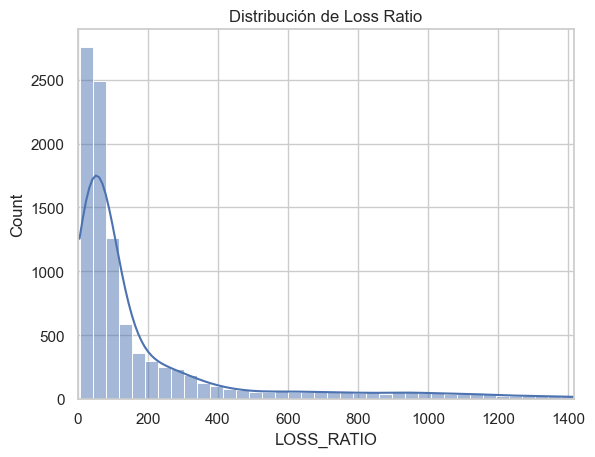

In [133]:
# Distribución (detectar riesgo real)
sns.histplot(df_model["LOSS_RATIO"], bins=50, kde=True)
plt.xlim(0, df_model["LOSS_RATIO"].quantile(0.99))  # cortar cola para ver forma
plt.title("Distribución de Loss Ratio")
plt.show()

- **Hallazgo 2 —  Concentración del riesgo en determinados productos (Life y Property)**

- Evidencia:
    - Life, 100% siniestros extremos
    - Property,  ~90% extremos
    - otros productos, mucho menor

- ¿Por qué es sospechoso? 
    - El riesgo debería estar distribuido entre productos
    - pero vemos que un tipo de seguro concentra casi todo el riesgo
    - comportamiento muy distinto entre productos

- Posibles causas: 
    - mala definición del producto
    - pricing incorrecto
    - falta de variables de riesgo
    - fraude en segmentos específicos

- Impacto en negocio
    - productos altamente deficitarios
    - necesidad de revisión urgente
    - priorización de controles

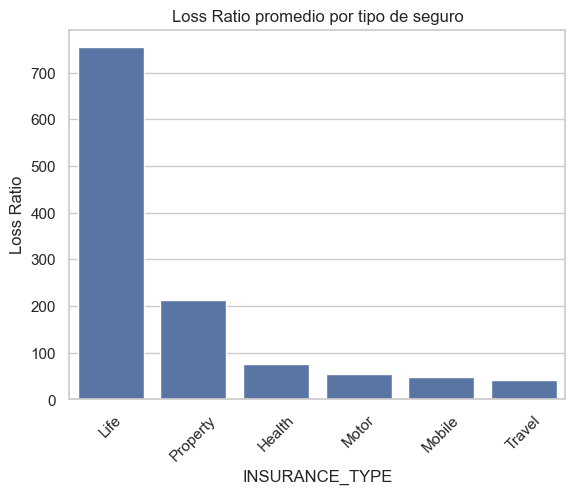

In [134]:
# Por tipo de seguro
# >1: producto deficitario
# ≈1: break-even (punto de equilibrio)
# <1: rentable
lr_by_type = df_model.groupby("INSURANCE_TYPE")["LOSS_RATIO"].mean().sort_values(ascending=False)
sns.barplot(x=lr_by_type.index, y=lr_by_type.values)
plt.xticks(rotation=45)
plt.title("Loss Ratio promedio por tipo de seguro")
plt.ylabel("Loss Ratio")
plt.show()

### 2.4 Escribí 2 insights accionables: qué encontraste, qué dato lo respalda y qué acción recomendarías.